## Module 3:

## Team Members:
Grace Lee, Kat Horn

## Project Title:
Lung Fibrosis and Interpolation



## Project Goal:
Intuitive, a medical company, seeks to find unknown lung fibrosis amounts at various lung depths. What is the predicted extent of lung fibrosis at various biopsy depths? How does the predicted lung fibrosis amount compare to the actual extent of lung fibrosis at that depth? Predicted lung fibrosis amounts will be interpolated from a few known sample points. 

## Disease Background: 



Global prevalence for idiopathic pulmonary fibrosis (IPF) is 17.7 out of 100,000 people. Global incidence is estimated to be around 5.8 out of 100,000. Prevalence and incidence rates varied by areas of study (Asia, versus Europe, versus North America). Compared to Europe and Asia, North America had the highest prevalence and incidence rates, which were 27.2 and 9.0 respectively (Golchin et al., 2025).



Several risk factors for IPF include old age, with IPF diagnosed more frequently in people in their 50s to 70s. Men are more likely to get IPF than women, with about 70% of all global cases presenting in men (Zaman & Lee, 2019). Additionally, a mutation in the MUC5B gene has been seen to be a significant risk factor of developing IPF (Michalski & Schwartz, 2021). Besides the MUC5B gene, other mutations in genes affecting alveolar stability, or surfactant proteins increase the risk of developing IPF. Having a sibilng or parent with the disease can increase the risk for developing IPF, with around 1 in 20 people with IPF having another family member with the condition (Idiopathic pulmonary fibrosis, 2017). Additionally, smoking is a significant lifestyle habit that increases the risk for developing IPF.



Symptoms of IPF inculude breathlessness, even with light activity such as getting dressed. Additionally, having a persistent cough, appetite and weight loss, fatigue, or swollen fingertips can be indicative of having IPF (Idiopathic pulmonary fibrosis, 2017).


While there is no cure for IPF, there are certain medications and treatments meant to slow the disease progression. Anti-fibrotic agents slow the rate of fibrosis in the lungs, such as nintedanib and pirfenidone. Oxygen treatments, through nasal tubes or an oxygen mask, can help people with IPF breath easier. Additionally, lifestyle treatments to slow disease progression are encouraged, such as quitting smoking, maintaining an active lifestyle, and staying away from people with chest infections or colds. In extreme cases, a lung transplant may be recommended (Idiopathic pulmonary fibrosis, 2017).


IPF is a chronic and progressive disease. Patients typically have a survival of 2.5 to 5 years, after getting diagnosed (Fujimoto et al., 2016). Additionally, the disease progression seems to vary among different patients. Some have a relatively slow decline, while others have rapid progression. Others may have periods of acute exacerbation, after which they decline more rapidly. It is difficult to predict the disease progression of an individual, but the disease does have a poor prognosis. 



IPF is characterized by excess scar tissue formation in the lungs. The cause of this fibrosis is unknown. Normally, when the alveolar lining, which allows gas exchange in the lungs, gets damaged, growth factors stimulate fibroblasts in the surrounding interstitial tissue to proliferate into myofibroblasts. These myofibroblasts secrete collagen and elastic fibers before undergoing apoptosis. However, in IPF, myofibroblasts over-proliferate and produce excess amounts of collagen and elastic fibers, and lung scarring. The interstitial layer thickens and causes the lungs to stiffen, making gas exchage of CO2 and O2 more difficult (Pham, 2018).  

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
Six sample images were taken from various lung depths, and converted into grayscale. From there, each pixel was determined to be either a white or black pixel, with white pixels indicating scar tissue in the lungs. The percentage of white pixels in each image was obtained for further analysis.

In [3]:
#importing standard libraries
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd

#loading 6 images to be analyzed
filenames = [
    r"/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/6 images/MASK_SK658 Slobe ch010089.jpg",
    r"/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/6 images/MASK_SK658 Slobe ch010105.jpg",
    r"/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/6 images/MASK_SK658 Slobe ch010118.jpg",
    r"/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/images/MASK_SK658 Slobe ch010093.jpg",
    r"/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/images/MASK_SK658 Slobe ch010066.jpg",
    r"/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/images/MASK_SK658 Slobe ch010110.jpg",
]

#entering the depths of each image, taken from the given 'Filenames and Depths for Students' .csv file
depths = [
    10000,
    8100,
    9900,
    9300,
    1000,
    5300,
]

#lists to store percent of white and black pixels, along with the percent of white pixels for each image
white_counts = []
black_counts = []
white_percents = []

The code below compiles and prints information about each image, including the number of white and black pixels, the percentage of white pixels, and the depths of the images. A CSV value was also created to store these percentages.

In [4]:
#Analyzing the images to find the counts of white and black pixels, as well as the percentage of white pixels in each image

print(colored("Counts of pixel by color in each image", "yellow"))

# Build the list of all the images you are analyzing

for i, (filename, depth) in enumerate(zip(filenames, depths)):
    img = cv2.imread(filename, 0)

    #Make the image greyscale
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)


    total = binary.size
    white = int(np.sum(binary == 255))
    black = total - white

    white_pct = 100 * white/total

    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_pct)

    print(colored(f"White pixels in image {i}: {white}", "white"))
    print(colored(f"Black pixels in image {i}: {black}", "black"))
    print()

#Print the percentage of white pixels in each image, along with the depth of each image
print(colored("Percent white px:", "yellow"))

for i, (filename, depth) in enumerate(zip(filenames, depths)):
    
    print(colored(f'{filenames[i]}:', "red"))
    print(f'{white_percents[i]}% White | Depth: {depths[i]} microns')
    print()


# Create a DataFrame that includes the filenames, depths, and percentage of white pixels
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Write that DataFrame to a .csv file

df.to_csv('Percent_White_Pixels.csv', index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")

Counts of pixel by color in each image
White pixels in image 0: 369855
Black pixels in image 0: 3824449

White pixels in image 1: 137688
Black pixels in image 1: 4056616

White pixels in image 2: 237289
Black pixels in image 2: 3957015

White pixels in image 3: 168932
Black pixels in image 3: 4025372

White pixels in image 4: 60715
Black pixels in image 4: 4133589

White pixels in image 5: 96012
Black pixels in image 5: 4098292

Percent white px:
/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/6 images/MASK_SK658 Slobe ch010089.jpg:
8.81803035736084% White | Depth: 10000 microns

/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/6 images/MASK_SK658 Slobe ch010105.jpg:
3.2827377319335938% White | Depth: 8100 microns

/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/6 images/MASK_SK658 Slobe ch010118.jpg:
5.657410621643066% White | Depth: 9900 microns

/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/

### Interpolation with a linear model

After analyzing the six images, the percentage of white pixels were graphed against the depth they were collected at. The below graph uses a linear model to interpolate and predict the percentage of white pixels at a depth of 7000 microns. The two datapoints surrounding the interpolated point are used to inform and predict the percentage of white pixels.

The interpolated point is at the x-coordinate 7000.0 and y-coordinate 2.8923818043300082.


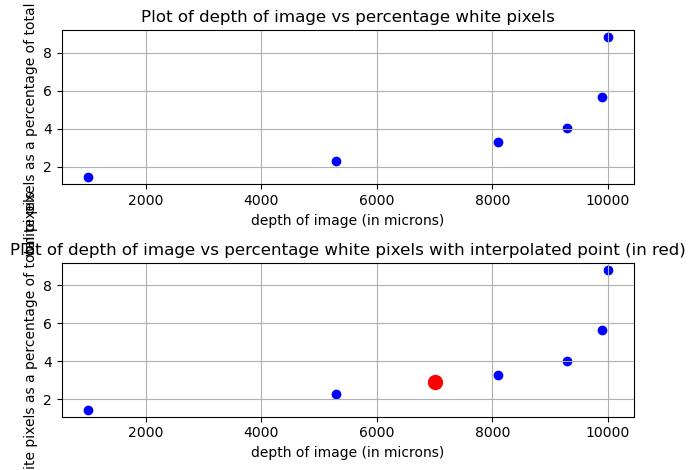

In [6]:
# # Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
   "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# # Specifying the interpolation method as linear
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

The top graph shows the percentage of white pixels of the six sample images plotted against depth. The bottom graph depicts where the interpolated point lies among the known data samples, using a linear interpolation model.

### Interpolation with a quadratic model

The below graph uses a linear model to interpolate and predict the percentage of white pixels at a depth of 7000 microns. The quadratic interpolation model uses three surrounding points to inform the interpolated result. 

The interpolated point is at the x-coordinate 7000.0 and y-coordinate 2.313197693006516.


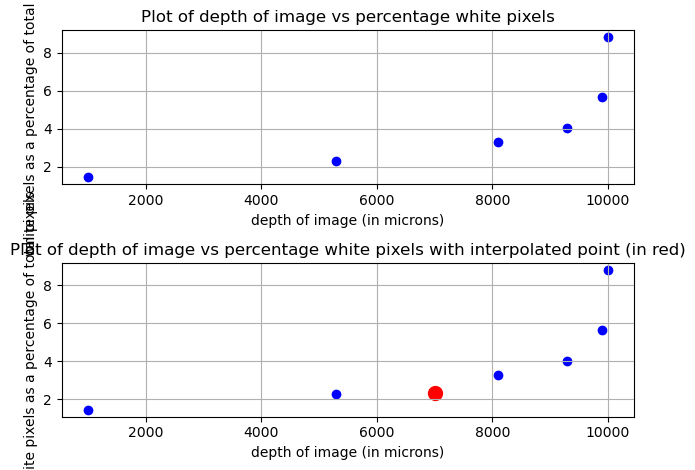

In [8]:
# # Interpolate a point: given a depth, find the corresponding white pixel percentage

interpolate_depth = float(input(colored(
   "Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))

x = depths
y = white_percents

# # Specifying the interpolation method as quadratic
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig2, axs2 = plt.subplots(2, 1)

axs2[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs2[0].set_title('Plot of depth of image vs percentage white pixels')
axs2[0].set_xlabel('depth of image (in microns)')
axs2[0].set_ylabel('white pixels as a percentage of total pixels')
axs2[0].grid(True)


axs2[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs2[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs2[1].set_xlabel('depth of image (in microns)')
axs2[1].set_ylabel('white pixels as a percentage of total pixels')
axs2[1].grid(True)
axs2[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

The top graph shows the percentage of white pixels of the six sample images plotted against depth. The bottom graph depicts where the inteprolated point lies among the known data samples, using a quadratic interpolation model.

## Verify and validate your analysis: 


The interpolated point was at a depth of 7000 microns. Image 'MASK_SK658 Slobe ch010130.jpg' was not originally analyzed in the original sample set and was taken at 7000 microns. The below code calculates the actual percentage of white pixels of a sample taken at 7000 microns. The predicted percentage white pixels were compared to the actual percentage white pixels in order to assess the accuracy and validity of the interpolation models.

In [27]:
#Make the image greyscale
img = cv2.imread("/Users/gracelee/Documents/computational BME/horn_lee_Module-3-Fibrosis/images/MASK_SK658 Slobe ch010130.jpg", 0)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)


total = binary.size
white = int(np.sum(binary == 255))
black = total - white

white_pct = 100 * white/total

white_counts.append(white)
black_counts.append(black)
white_percents.append(white_pct)

print(colored(f"Percentage of white pixels in image: {white_pct}%", "yellow"))
print()

Percentage of white pixels in image: 2.684903144836426%



At a depth of 7000 microns, the true percentage of white pixels (taken from the image at that depth) is 2.68%. 

Using a linear interpolation model, the predicted percentage of white pixels at 7000 microns was 2.89%.
Using a quadratic interpolation model, the predicted percentage of white pixels at 7000 microns was 2.31%. 

The relative error of the linear interpolation model is 7.8%, while the relative error of the quadratic interpolation model is 13.8%.

From this, it seems that the linear interpolation model was a better estimate of pixel percentage compared to the quadratic interpolation model. 

## Conclusions and Ethical Implications: 
This project aimed to estimate the extent of lung fibrosis at various depths using interpolation based on a limited number of sampled images. By converting lung biopsy images into binary form and quantifying the percentage of white pixels (representing fibrotic tissue), we established a relationship between depth and fibrosis severity.

Both linear and quadratic interpolation models were used to predict fibrosis at an unsampled depth of 7000 microns. When compared to the actual measured value (2.68%), the linear model (2.89%, 7.8% error) outperformed the quadratic model (2.31%, 13.8% error). This suggests that, for this dataset, fibrosis progression with depth may be more accurately approximated as locally linear rather than curved. More broadly, this demonstrates that relatively simple mathematical models can provide reasonably accurate predictions in biological systems when data is limited.

From a clinical perspective, this type of interpolation could help reduce the number of biopsies required to assess disease progression, minimizing patient discomfort and risk. However, ethical considerations arise when relying on predictive models in medical decision-making. Inaccurate predictions could lead to misjudgment of disease severity, potentially resulting in under- or over-treatment. Therefore, interpolation models like those used in this study should be applied cautiously and always validated against real patient data before being used in clinical settings.

Additionally, there are ethical considerations regarding data interpretation. Since image processing decisions (such as thresholding) directly influence fibrosis estimates, biased or inconsistent processing could misrepresent disease severity. Transparency in methodology and validation is essential to ensure that such computational tools are used responsibly in healthcare.

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

limitations to data set:
desmin binds to blood arteries (some of the white pixels are due to blood vessels, may overestimate fibrosis amounts)
mouse lungs are not upright as in humans (maybe not the most accurate model)

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*

- Fujimoto, H., Kobayashi, T., & Azuma, A. (2016). Idiopathic Pulmonary Fibrosis: Treatment and Prognosis. Clinical medicine insights. Circulatory, respiratory and pulmonary medicine, 9(Suppl 1), 179–185. https://doi.org/10.4137/CCRPM.S23321
- Golchin, N., Patel, A., Scheuring, J., Wan, V., Hofer, K., Collet, J. P., Elpers, B., & Lesperance, T. (2025). Incidence and prevalence of idiopathic pulmonary fibrosis: a systematic literature review and meta-analysis. BMC pulmonary medicine, 25(1), 378. https://doi.org/10.1186/s12890-025-03836-1
- Idiopathic pulmonary fibrosis. (2017, October 23). NHS. https://www.nhs.uk/conditions/idiopathic-pulmonary-fibrosis/
- Michalski, J. E., & Schwartz, D. A. (2021). Genetic Risk Factors for Idiopathic Pulmonary Fibrosis: Insights into Immunopathogenesis. Journal of inflammation research, 13, 1305–1318. https://doi.org/10.2147/JIR.S280958
- Pham, H. L.. (2018, January 3). Idiopathic pulmonary fibrosis causes, symptoms, diagnosis, treatment, pathology [Video]. YouTube. https://www.youtube.com/watch?v=Z6_0WkceY88
- Zaman, T., & Lee, J. S. (2018). Risk factors for the development of idiopathic pulmonary fibrosis: A review. Current pulmonology reports, 7(4), 118–125. https://doi.org/10.1007/s13665-018-0210-7
